# Nassau Candy Distributor — Product Line Profitability & Margin Performance Analysis

This notebook covers:
1. Data Cleaning & Validation
2. Feature Engineering
3. Product-Level Profitability Analysis
4. Division-Level Performance Analysis
5. Time-Based / Growth Analysis
6. Profit Concentration (Pareto) Analysis
7. Cost Structure Diagnostics
8. Key Findings Summary

## 0. Setup & Data Load

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Nassau Candy Distributor.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [2]:
df.shape

(10194, 18)

In [3]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Country/Region',
 'City',
 'State/Province',
 'Postal Code',
 'Division',
 'Region',
 'Product ID',
 'Product Name',
 'Sales',
 'Units',
 'Gross Profit',
 'Cost']

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

## 1. Data Cleaning & Validation

### 1.1 Missing values, duplicates, ID integrity

In [5]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["Row ID"].nunique()

10194

In [8]:
df["Order ID"].nunique()

8549

In [9]:
# Each Order ID should belong to exactly one customer and one order date
print("Max customers per Order ID:", df.groupby("Order ID")["Customer ID"].nunique().max())
print("Max order dates per Order ID:", df.groupby("Order ID")["Order Date"].nunique().max())

Max customers per Order ID: 1
Max order dates per Order ID: 1


### 1.2 Impossible values (negative / zero checks)

In [10]:
for col in ["Sales", "Units", "Cost", "Gross Profit"]:
    print(f"--- {col} ---")
    print("Negative:", (df[col] < 0).sum())
    print("Zero:", (df[col] == 0).sum())
    print("Minimum:", df[col].min())
    print()

--- Sales ---
Negative: 0
Zero: 0
Minimum: 1.25

--- Units ---
Negative: 0
Zero: 0
Minimum: 1

--- Cost ---
Negative: 0
Zero: 0
Minimum: 0.6

--- Gross Profit ---
Negative: 0
Zero: 0
Minimum: 0.25



### 1.3 Verify Gross Profit = Sales - Cost

In [11]:
df["Calculated Profit"] = df["Sales"] - df["Cost"]
mismatches_exact = (df["Gross Profit"] != df["Calculated Profit"]).sum()
mismatches_rounded = (df["Gross Profit"].round(2) != df["Calculated Profit"].round(2)).sum()

print("Mismatches (exact):", mismatches_exact, "-> these are floating point rounding noise")
print("Mismatches (rounded to 2dp):", mismatches_rounded, "-> true mismatches")

df.drop(columns=["Calculated Profit"], inplace=True)

Mismatches (exact): 3809 -> these are floating point rounding noise
Mismatches (rounded to 2dp): 0 -> true mismatches


### 1.4 Date parsing & Ship Date data quality check

**Known issue:** Ship Date consistently falls 3-4 years after Order Date
(e.g. Order Date in 2024-2025, Ship Date in 2026-2030). This is not a
parsing error — the raw values themselves are inconsistent with a real
shipping timeline. Ship Date is therefore treated as unreliable and
excluded from any time-based analysis in this notebook.

In [12]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

print("Order Date range:", df["Order Date"].min(), "to", df["Order Date"].max())
print("Ship Date range:", df["Ship Date"].min(), "to", df["Ship Date"].max())

sd = (df["Ship Date"] - df["Order Date"]).dt.days
print("Avg days between order and ship:", round(sd.mean(), 1), "(implausible - confirms Ship Date is unreliable)")

Order Date range: 2024-01-02 00:00:00 to 2025-12-31 00:00:00
Ship Date range: 2026-06-30 00:00:00 to 2030-06-28 00:00:00
Avg days between order and ship: 1320.8 (implausible - confirms Ship Date is unreliable)


### 1.5 Category consistency (whitespace, casing) & outlier check

In [13]:
categorical_cols = ["Order ID", "Ship Mode", "Country/Region", "City",
                     "State/Province", "Division", "Region", "Product ID", "Product Name"]
for col in categorical_cols:
    spaces = df[col].astype(str).str.strip().ne(df[col].astype(str)).sum()
    print(f"{col}: {spaces} values with leading/trailing spaces")

Order ID: 0 values with leading/trailing spaces
Ship Mode: 0 values with leading/trailing spaces
Country/Region: 0 values with leading/trailing spaces
City: 0 values with leading/trailing spaces
State/Province: 0 values with leading/trailing spaces
Division: 0 values with leading/trailing spaces
Region: 0 values with leading/trailing spaces
Product ID: 0 values with leading/trailing spaces
Product Name: 0 values with leading/trailing spaces


In [14]:
# IQR outlier check — checked for data-entry errors, not for removal.
# High-value orders here are legitimate larger purchases, not errors, so
# nothing is dropped; this is documented rather than acted on.
for col in ["Sales", "Cost", "Gross Profit", "Units"]:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    print(f"{col}: upper bound={upper:.2f}, outliers={(df[col] > upper).sum()}")

Sales: upper bound=34.20, outliers=245


Cost: upper bound=10.65, outliers=397
Gross Profit: upper bound=23.27, outliers=217
Units: upper bound=9.50, outliers=175


### 1.6 Product ID <-> Product Name consistency

In [15]:
product_id_check = df.groupby("Product ID")["Product Name"].nunique()
print("Max product names per Product ID:", product_id_check.max())
print("Product IDs linked to multiple names:", (product_id_check > 1).sum())

Max product names per Product ID: 1
Product IDs linked to multiple names: 0


**Cleaning summary:** No missing values, no duplicate rows, no negative/zero
Sales, Cost, Units, or Gross Profit, no whitespace inconsistencies, and no
Product ID/Name mismatches. The only data quality issue found is the
unreliable Ship Date field (documented above, excluded from analysis).

## 2. Feature Engineering

In [16]:
df["Year"] = df["Order Date"].dt.year

## 3. Product-Level Profitability Analysis

KPI definitions:
- **Gross Margin %** = Gross Profit / Sales
- **Profit per Unit** = Gross Profit / Units
- **Revenue Contribution %** = product's Sales / total Sales
- **Profit Contribution %** = product's Gross Profit / total Gross Profit

In [17]:
product = df.groupby(["Division", "Product Name"]).agg(
    Total_Sales=("Sales", "sum"),
    Total_Units=("Units", "sum"),
    Total_Gross_Profit=("Gross Profit", "sum"),
    Total_Cost=("Cost", "sum")
).reset_index()

total_sales = product["Total_Sales"].sum()
total_profit = product["Total_Gross_Profit"].sum()

product["Gross_Margin_%"] = (product["Total_Gross_Profit"] / product["Total_Sales"] * 100).round(1)
product["Profit_per_Unit"] = (product["Total_Gross_Profit"] / product["Total_Units"]).round(2)
product["Revenue_Contribution_%"] = (product["Total_Sales"] / total_sales * 100).round(1)
product["Profit_Contribution_%"] = (product["Total_Gross_Profit"] / total_profit * 100).round(1)

product = product.sort_values("Total_Gross_Profit", ascending=False).reset_index(drop=True)
product

,Division,Product Name,Total_Sales,Total_Units,Total_Gross_Profit,Total_Cost,Gross_Margin_%,Profit_per_Unit,Revenue_Contribution_%,Profit_Contribution_%
0,Chocolate,Wonka Bar -Scrumdiddlyumptious,27874.80,7743,19357.50,8517.30,69.4,2.50,19.7,20.7
1,Chocolate,Wonka Bar - Triple Dazzle Caramel,28485.00,7596,18610.20,9874.80,65.3,2.45,20.1,19.9
2,Chocolate,Wonka Bar - Milk Chocolate,26867.75,8267,17443.37,9424.38,64.9,2.11,18.9,18.7
3,Chocolate,Wonka Bar - Nutty Crunch Surprise,23574.95,6755,16819.95,6755.00,71.3,2.49,16.6,18.0
4,Chocolate,Wonka Bar - Fudge Mallows,24890.40,6914,16593.60,8296.80,66.7,2.40,17.6,17.8
5,Other,Lickable Wallpaper,7860.00,393,3930.00,3930.00,50.0,10.00,5.5,4.2
6,Other,Wonka Gum,597.50,478,310.70,286.80,52.0,0.65,0.4,0.3
7,Sugar,Everlasting Gobstopper,130.00,13,104.00,26.00,80.0,8.00,0.1,0.1
8,Other,Kazookles,1205.75,371,92.75,1113.00,7.7,0.25,0.9,0.1
9,Sugar,Hair Toffee,76.50,17,59.50,17.00,77.8,3.50,0.1,0.1


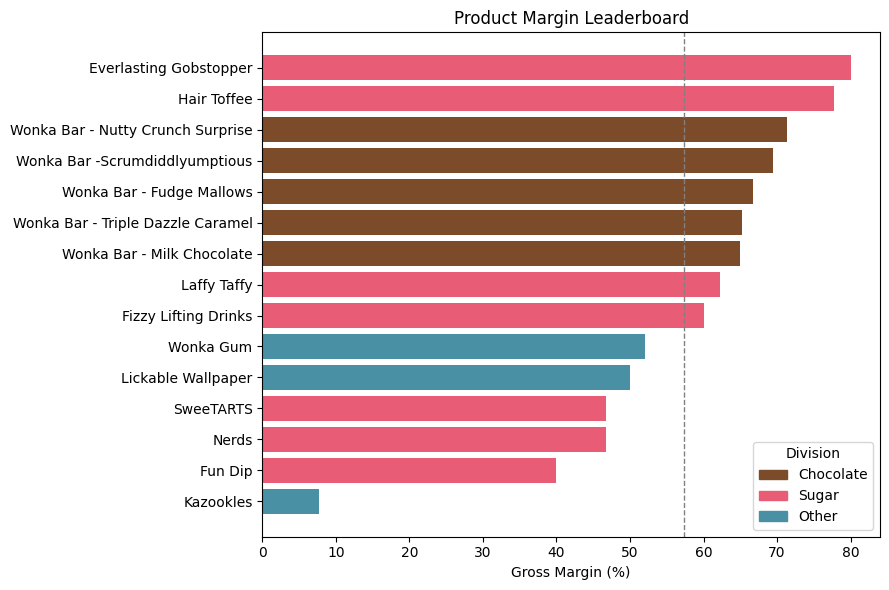

In [18]:
# Margin leaderboard chart
plot_df = product.sort_values("Gross_Margin_%")
colors = {"Chocolate": "#7B4B2A", "Sugar": "#E85D75", "Other": "#4A90A4"}
bar_colors = plot_df["Division"].map(colors)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_df["Product Name"], plot_df["Gross_Margin_%"], color=bar_colors)
ax.axvline(plot_df["Gross_Margin_%"].mean(), color="gray", linestyle="--", linewidth=1,
           label=f"Avg margin ({plot_df['Gross_Margin_%'].mean():.0f}%)")
ax.set_xlabel("Gross Margin (%)")
ax.set_title("Product Margin Leaderboard")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
ax.legend(handles, colors.keys(), loc="lower right", title="Division")
plt.tight_layout()
plt.show()

### 3.1 Product Profitability Classification

Products are classified based on their sales volume and gross margin.
Median sales and median gross margin are used as analytical thresholds.

In [19]:
# Product profitability classification

sales_median = product["Total_Sales"].median()
margin_median = product["Gross_Margin_%"].median()

def classify_product(row):
    if row["Total_Sales"] >= sales_median and row["Gross_Margin_%"] >= margin_median:
        return "High Sales - High Margin"
    elif row["Total_Sales"] >= sales_median and row["Gross_Margin_%"] < margin_median:
        return "High Sales - Low Margin"
    elif row["Total_Sales"] < sales_median and row["Gross_Margin_%"] >= margin_median:
        return "Low Sales - High Margin"
    else:
        return "Low Sales - Low Margin"

product["Profitability_Class"] = product.apply(
    classify_product,
    axis=1
)

product[
    [
        "Product Name",
        "Division",
        "Total_Sales",
        "Total_Gross_Profit",
        "Gross_Margin_%",
        "Profit_per_Unit",
        "Profitability_Class"
    ]
].sort_values(
    "Total_Gross_Profit",
    ascending=False
)

,Product Name,Division,Total_Sales,Total_Gross_Profit,Gross_Margin_%,Profit_per_Unit,Profitability_Class
0,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,19357.50,69.4,2.50,High Sales - High Margin
1,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,18610.20,65.3,2.45,High Sales - High Margin
2,Wonka Bar - Milk Chocolate,Chocolate,26867.75,17443.37,64.9,2.11,High Sales - High Margin
3,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,16819.95,71.3,2.49,High Sales - High Margin
4,Wonka Bar - Fudge Mallows,Chocolate,24890.40,16593.60,66.7,2.40,High Sales - High Margin
5,Lickable Wallpaper,Other,7860.00,3930.00,50.0,10.00,High Sales - Low Margin
6,Wonka Gum,Other,597.50,310.70,52.0,0.65,High Sales - Low Margin
7,Everlasting Gobstopper,Sugar,130.00,104.00,80.0,8.00,Low Sales - High Margin
8,Kazookles,Other,1205.75,92.75,7.7,0.25,High Sales - Low Margin
9,Hair Toffee,Sugar,76.50,59.50,77.8,3.50,Low Sales - High Margin


### 3.2 Product Profitability Matrix

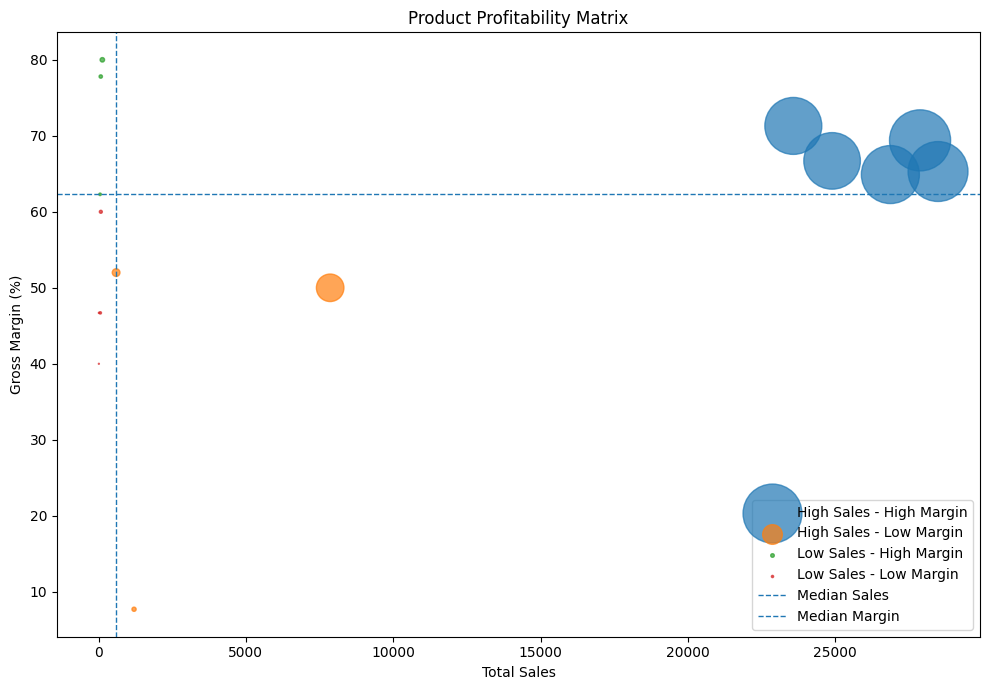

In [20]:
# Product Profitability Matrix

plt.figure(figsize=(10, 7))

for category in product["Profitability_Class"].unique():
    subset = product[
        product["Profitability_Class"] == category
    ]

    plt.scatter(
        subset["Total_Sales"],
        subset["Gross_Margin_%"],
        s=subset["Total_Gross_Profit"] / 10,
        alpha=0.7,
        label=category
    )

plt.axvline(
    sales_median,
    linestyle="--",
    linewidth=1,
    label="Median Sales"
)

plt.axhline(
    margin_median,
    linestyle="--",
    linewidth=1,
    label="Median Margin"
)

plt.xlabel("Total Sales")
plt.ylabel("Gross Margin (%)")
plt.title("Product Profitability Matrix")
plt.legend()
plt.tight_layout()
plt.show()

**Finding:** The 5 Chocolate products cluster tightly at 65-71% margin —
consistent and reliable. Kazookles stands out sharply at 7.7% margin,
well below every other product.

## 4. Division-Level Performance Analysis

In [21]:
division = df.groupby("Division").agg(
    Total_Sales=("Sales", "sum"),
    Total_Units=("Units", "sum"),
    Total_Gross_Profit=("Gross Profit", "sum"),
    Orders=("Row ID", "count")
).reset_index()

division["Gross_Margin_%"] = (division["Total_Gross_Profit"] / division["Total_Sales"] * 100).round(1)
division["Revenue_Share_%"] = (division["Total_Sales"] / division["Total_Sales"].sum() * 100).round(1)
division["Profit_Share_%"] = (division["Total_Gross_Profit"] / division["Total_Gross_Profit"].sum() * 100).round(1)
division = division.sort_values("Total_Gross_Profit", ascending=False)
division

,Division,Total_Sales,Total_Units,Total_Gross_Profit,Orders,Gross_Margin_%,Revenue_Share_%,Profit_Share_%
0,Chocolate,131692.90,37275,88824.62,9844,67.4,92.9,95.1
1,Other,9663.25,1242,4333.45,310,44.8,6.8,4.6
2,Sugar,427.48,137,284.73,40,66.6,0.3,0.3


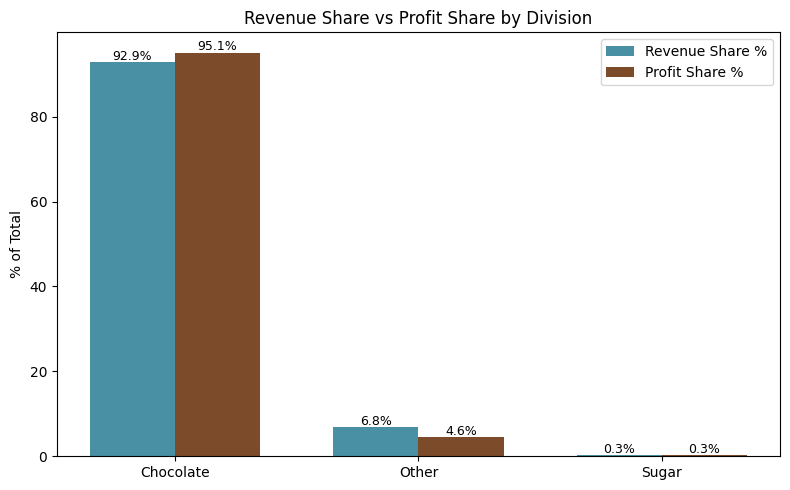

In [22]:
import numpy as np
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(division))
width = 0.35
b1 = ax.bar(x - width/2, division["Revenue_Share_%"], width, label="Revenue Share %", color="#4A90A4")
b2 = ax.bar(x + width/2, division["Profit_Share_%"], width, label="Profit Share %", color="#7B4B2A")
ax.set_xticks(x)
ax.set_xticklabels(division["Division"])
ax.set_ylabel("% of Total")
ax.set_title("Revenue Share vs Profit Share by Division")
ax.legend()
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{h}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

**Finding:** Chocolate converts revenue to profit more efficiently than
the business average (95.1% of profit from 92.9% of revenue). "Other"
does the opposite — a smaller share of profit (4.6%) than its revenue
share (6.8%) would suggest.

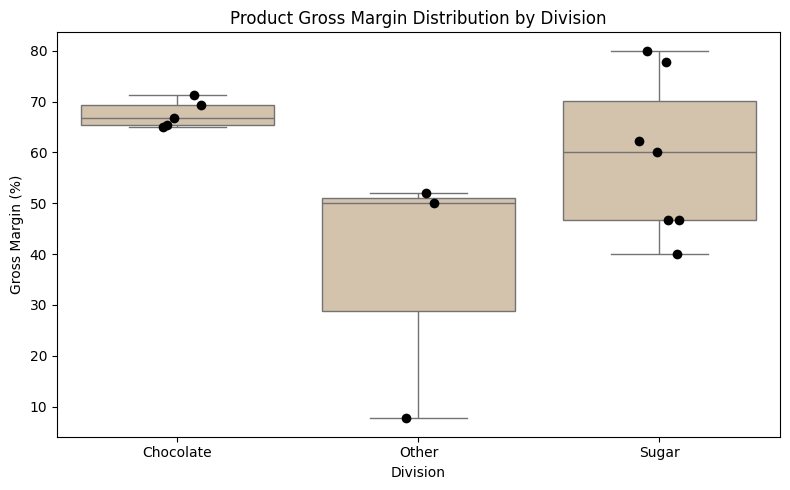

,count,min,mean,max
Division,,,,
Chocolate,5,64.9,67.5,71.3
Other,3,7.7,36.6,52.0
Sugar,7,40.0,59.1,80.0


In [23]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=product, x="Division", y="Gross_Margin_%", color="#d9c3a5", ax=ax)
sns.stripplot(data=product, x="Division", y="Gross_Margin_%", color="black", size=7, ax=ax)
ax.set_ylabel("Gross Margin (%)")
ax.set_title("Product Gross Margin Distribution by Division")
plt.tight_layout(); plt.show()

product.groupby("Division")["Gross_Margin_%"].agg(["count", "min", "mean", "max"]).round(1)

**Finding:** Chocolate is both high and tightly clustered (about 65–71%). Sugar is wide (40–80%), so its division average hides very different products. Other has only three products: two at about 50–52% and Kazookles at 7.7%, which is why its division margin is the weakest.

## 5. Time-Based / Growth Analysis

In [24]:
yearly_sales = df.groupby("Year").agg(
    Total_Sales=("Sales", "sum"),
    Total_Cost=("Cost", "sum"),
    Total_Gross_Profit=("Gross Profit", "sum"),
    Total_Units=("Units", "sum")
).reset_index()
yearly_sales

,Year,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units
0,2024,57956.20,19804.77,38151.43,15899
1,2025,83827.43,28536.06,55291.37,22755


In [25]:
sales_growth = (
    (yearly_sales.loc[yearly_sales["Year"] == 2025, "Total_Sales"].iloc[0] /
     yearly_sales.loc[yearly_sales["Year"] == 2024, "Total_Sales"].iloc[0]) - 1
) * 100
profit_growth = (
    (yearly_sales.loc[yearly_sales["Year"] == 2025, "Total_Gross_Profit"].iloc[0] /
     yearly_sales.loc[yearly_sales["Year"] == 2024, "Total_Gross_Profit"].iloc[0]) - 1
) * 100

top_product_sales = product.loc[product["Total_Sales"].idxmax(), "Product Name"]
top_product_profit = product.loc[product["Total_Gross_Profit"].idxmax(), "Product Name"]

region_analysis = df.groupby("Region").agg(Total_Sales=("Sales", "sum")).reset_index()
top_region = region_analysis.loc[region_analysis["Total_Sales"].idxmax(), "Region"]

print("Sales Growth:", round(sales_growth, 2), "%")
print("Gross Profit Growth:", round(profit_growth, 2), "%")
print("Top Product by Sales:", top_product_sales)
print("Top Product by Profit:", top_product_profit)
print("Top Region:", top_region)

Sales Growth: 44.64 %
Gross Profit Growth: 44.93 %
Top Product by Sales: Wonka Bar - Triple Dazzle Caramel
Top Product by Profit: Wonka Bar -Scrumdiddlyumptious
Top Region: Pacific


**Finding:** Sales grew 44.6% and profit grew 44.9% year-over-year —
growth was achieved without sacrificing margin, since the two rates
track almost exactly.

### 5.1 Product Margin Volatility

Margin volatility measures how much a product's gross margin changes across years.
A higher standard deviation indicates less stable profitability.

In [26]:
# Product-level margin volatility over time

yearly_product = df.groupby(
    ["Product Name", "Year"]
).agg(
    Sales=("Sales", "sum"),
    Gross_Profit=("Gross Profit", "sum")
).reset_index()

yearly_product["Margin_%"] = (
    yearly_product["Gross_Profit"]
    / yearly_product["Sales"]
    * 100
)

margin_volatility = (
    yearly_product
    .groupby("Product Name")["Margin_%"]
    .agg(
        Average_Margin="mean",
        Margin_Volatility="std",
        Minimum_Margin="min",
        Maximum_Margin="max"
    )
    .reset_index()
)

margin_volatility = margin_volatility.sort_values(
    "Margin_Volatility",
    ascending=False
)

margin_volatility

,Product Name,Average_Margin,Margin_Volatility,Minimum_Margin,Maximum_Margin
7,Nerds,46.666667,7.105427e-15,46.666667,46.666667
1,Fizzy Lifting Drinks,60.000000,0.000000e+00,60.000000,60.000000
5,Laffy Taffy,62.311558,0.000000e+00,62.311558,62.311558
4,Kazookles,7.692308,0.000000e+00,7.692308,7.692308
6,Lickable Wallpaper,50.000000,0.000000e+00,50.000000,50.000000
8,SweeTARTS,46.666667,0.000000e+00,46.666667,46.666667
9,Wonka Bar - Fudge Mallows,66.666667,0.000000e+00,66.666667,66.666667
10,Wonka Bar - Milk Chocolate,64.923077,0.000000e+00,64.923077,64.923077
11,Wonka Bar - Nutty Crunch Surprise,71.346705,0.000000e+00,71.346705,71.346705
12,Wonka Bar - Triple Dazzle Caramel,65.333333,0.000000e+00,65.333333,65.333333


In [27]:
# Monthly margin volatility (more data points than the 2 yearly values)
monthly = df.assign(Month=df["Order Date"].dt.to_period("M")).groupby(["Product Name", "Month"]).agg(
    Sales=("Sales", "sum"), Gross_Profit=("Gross Profit", "sum")).reset_index()
monthly["Margin_%"] = monthly["Gross_Profit"] / monthly["Sales"] * 100

vol_monthly = monthly.groupby("Product Name")["Margin_%"].agg(
    Months="count", Average_Margin="mean", Margin_Volatility="std").reset_index()
vol_monthly["Margin_Volatility"] = vol_monthly["Margin_Volatility"].fillna(0).round(4)
vol_monthly.sort_values("Margin_Volatility", ascending=False)

,Product Name,Months,Average_Margin,Margin_Volatility
0,Everlasting Gobstopper,3,80.000000,0.0
1,Fizzy Lifting Drinks,5,60.000000,0.0
2,Fun Dip,2,40.000000,0.0
3,Hair Toffee,3,77.777778,0.0
4,Kazookles,23,7.692308,0.0
5,Laffy Taffy,7,62.311558,0.0
6,Lickable Wallpaper,20,50.000000,0.0
7,Nerds,4,46.666667,0.0
8,SweeTARTS,8,46.666667,0.0
9,Wonka Bar - Fudge Mallows,24,66.666667,0.0


**Finding:** Margin volatility is 0 for every product, whether measured yearly or monthly. Each product is sold at a fixed unit price and cost, so its margin never changes over time. Margin risk in this dataset is therefore **structural** (which product you sell), not **time-driven**: low-margin products such as Kazookles will stay low until price or cost changes.

## 6. Profit Concentration (Pareto) Analysis

In [28]:
pareto = product.sort_values("Total_Gross_Profit", ascending=False).reset_index(drop=True)
pareto["Cumulative_Profit_%"] = (pareto["Total_Gross_Profit"].cumsum() / pareto["Total_Gross_Profit"].sum() * 100).round(1)
n_for_80 = (pareto["Cumulative_Profit_%"] < 80).sum() + 1
print(f"Products needed to reach 80% of profit: {n_for_80} of {len(pareto)} ({n_for_80/len(pareto)*100:.0f}% of the product line)")
pareto[["Product Name", "Total_Gross_Profit", "Profit_Contribution_%", "Cumulative_Profit_%"]]

Products needed to reach 80% of profit: 5 of 15 (33% of the product line)


,Product Name,Total_Gross_Profit,Profit_Contribution_%,Cumulative_Profit_%
0,Wonka Bar -Scrumdiddlyumptious,19357.50,20.7,20.7
1,Wonka Bar - Triple Dazzle Caramel,18610.20,19.9,40.6
2,Wonka Bar - Milk Chocolate,17443.37,18.7,59.3
3,Wonka Bar - Nutty Crunch Surprise,16819.95,18.0,77.3
4,Wonka Bar - Fudge Mallows,16593.60,17.8,95.1
5,Lickable Wallpaper,3930.00,4.2,99.3
6,Wonka Gum,310.70,0.3,99.6
7,Everlasting Gobstopper,104.00,0.1,99.7
8,Kazookles,92.75,0.1,99.8
9,Hair Toffee,59.50,0.1,99.9


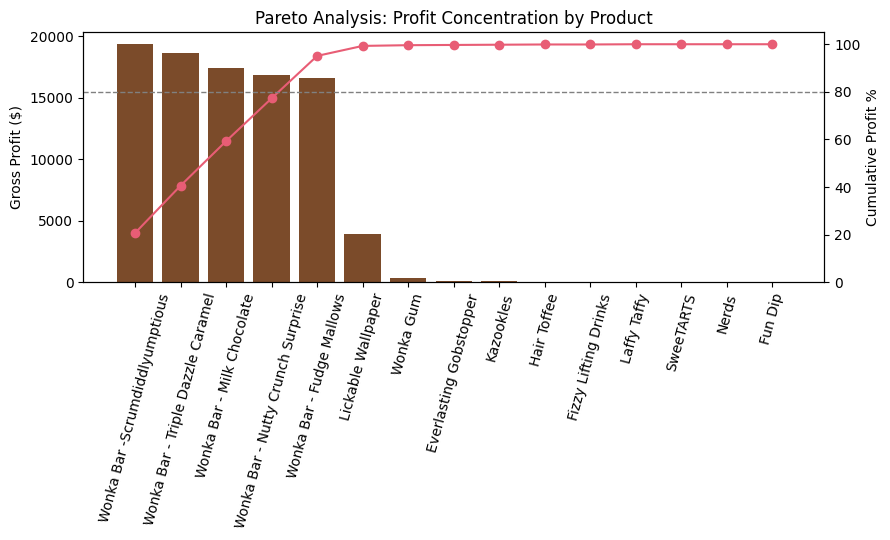

In [29]:
fig, ax1 = plt.subplots(figsize=(9, 5.5))
ax1.bar(pareto["Product Name"], pareto["Total_Gross_Profit"], color="#7B4B2A")
ax1.set_ylabel("Gross Profit ($)")
ax1.tick_params(axis="x", rotation=75)
ax2 = ax1.twinx()
ax2.plot(pareto["Product Name"], pareto["Cumulative_Profit_%"], color="#E85D75", marker="o")
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Cumulative Profit %")
ax2.set_ylim(0, 105)
plt.title("Pareto Analysis: Profit Concentration by Product")
plt.tight_layout()
plt.show()

### 6.1 Revenue Pareto Analysis

In [30]:
# Revenue Pareto Analysis

revenue_pareto = (
    product
    .sort_values("Total_Sales", ascending=False)
    .reset_index(drop=True)
)

revenue_pareto["Cumulative_Revenue_%"] = (
    revenue_pareto["Total_Sales"].cumsum()
    / revenue_pareto["Total_Sales"].sum()
    * 100
)

n_for_80_revenue = (
    revenue_pareto["Cumulative_Revenue_%"]
    .ge(80)
    .idxmax()
    + 1
)

print(
    f"Products needed to reach 80% of revenue: "
    f"{n_for_80_revenue} of {len(revenue_pareto)} "
    f"({n_for_80_revenue / len(revenue_pareto) * 100:.0f}% of product line)"
)

revenue_pareto[
    [
        "Product Name",
        "Total_Sales",
        "Revenue_Contribution_%",
        "Cumulative_Revenue_%"
    ]
]

Products needed to reach 80% of revenue: 5 of 15 (33% of product line)


,Product Name,Total_Sales,Revenue_Contribution_%,Cumulative_Revenue_%
0,Wonka Bar - Triple Dazzle Caramel,28485.00,20.1,20.090472
1,Wonka Bar -Scrumdiddlyumptious,27874.80,19.7,39.750569
2,Wonka Bar - Milk Chocolate,26867.75,18.9,58.700394
3,Wonka Bar - Fudge Mallows,24890.40,17.6,76.255595
4,Wonka Bar - Nutty Crunch Surprise,23574.95,16.6,92.883008
5,Lickable Wallpaper,7860.00,5.5,98.426666
6,Kazookles,1205.75,0.9,99.277082
7,Wonka Gum,597.50,0.4,99.698498
8,Everlasting Gobstopper,130.00,0.1,99.790187
9,Fizzy Lifting Drinks,78.75,0.1,99.845730


### 6.2 Revenue vs Profit Concentration

In [31]:
# Compare revenue and profit concentration

print(
    f"Products needed for 80% of revenue: "
    f"{n_for_80_revenue}"
)

print(
    f"Products needed for 80% of profit: "
    f"{n_for_80}"
)

print(
    f"Total products: "
    f"{len(product)}"
)

Products needed for 80% of revenue: 5
Products needed for 80% of profit: 5
Total products: 15


**Finding:** Just 5 products (33% of the line) generate 95.1% of profit —
more extreme than a typical 80/20 split. The business is heavily
dependent on the Chocolate/Wonka Bar line.

### 6.3 Dependency Indicators

In [32]:
prof = product.sort_values("Total_Gross_Profit", ascending=False)["Total_Gross_Profit"]
shares = prof / prof.sum()

top1, top3, top5 = shares.iloc[0]*100, shares.head(3).sum()*100, shares.head(5).sum()*100
hhi = (shares**2).sum() * 10000   # Herfindahl-Hirschman Index (0-10,000)

if top3 >= 50 or top5 >= 80 or hhi >= 2500: level = "HIGH"
elif top3 >= 35 or top5 >= 60 or hhi >= 1500: level = "MODERATE"
else: level = "LOW"

print(f"Top-1 product share of profit : {top1:.1f}%")
print(f"Top-3 products share of profit: {top3:.1f}%")
print(f"Top-5 products share of profit: {top5:.1f}%")
print(f"Profit HHI                    : {hhi:,.0f}")
print(f"Dependency risk level         : {level}")

Top-1 product share of profit : 20.7%
Top-3 products share of profit: 59.3%
Top-5 products share of profit: 95.1%
Profit HHI                    : 1,831
Dependency risk level         : HIGH


**Finding:** No single product dominates (top product = 20.7% of profit), but three products produce 59.3% and five produce 95.1%. The risk lies in the whole Wonka Bar line, not in one SKU: a problem affecting the chocolate division (supply, pricing, demand) would hit almost all profit.

## 7. Cost Structure Diagnostics

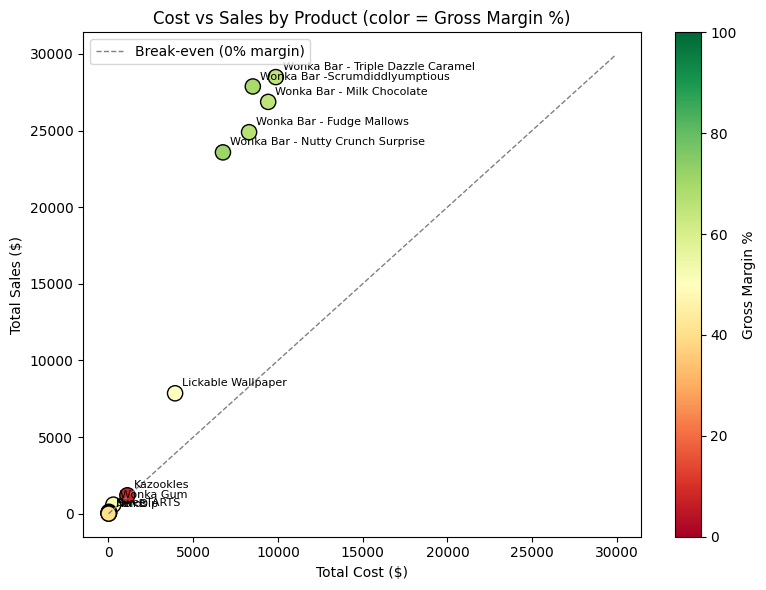

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(product["Total_Cost"], product["Total_Sales"],
                 c=product["Gross_Margin_%"], cmap="RdYlGn", s=120, edgecolor="black", vmin=0, vmax=100)
max_val = max(product["Total_Cost"].max(), product["Total_Sales"].max()) * 1.05
ax.plot([0, max_val], [0, max_val], linestyle="--", color="gray", linewidth=1, label="Break-even (0% margin)")
for _, row in product.iterrows():
    if row["Gross_Margin_%"] < 55 or row["Total_Sales"] > 20000:
        ax.annotate(row["Product Name"], (row["Total_Cost"], row["Total_Sales"]), fontsize=8,
                    xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("Total Cost ($)")
ax.set_ylabel("Total Sales ($)")
ax.set_title("Cost vs Sales by Product (color = Gross Margin %)")
cbar = plt.colorbar(sc)
cbar.set_label("Gross Margin %")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Finding:** Kazookles sits almost on the break-even line — a clear
repricing / cost-renegotiation candidate. The 5 Wonka Bars cluster
together comfortably above the line with a consistent cost structure.

### 7.1 Margin Risk Flags (Reprice / Cost Renegotiation / Discontinuation Review)

Rules: margin below 20% → **Reprice**; margin below 20% *and* under 2% of revenue → also **Discontinuation review**; cost-to-sales more than 10 pp above the division average → **Cost renegotiation**.

In [34]:
LOW_MARGIN, COST_GAP, SMALL_SHARE = 20, 10, 2

flags = product.copy()
flags["Cost_to_Sales_%"] = flags["Total_Cost"] / flags["Total_Sales"] * 100
div_cost = flags.groupby("Division")[["Total_Cost", "Total_Sales"]].sum()
flags["Division_Cost_Ratio_%"] = flags["Division"].map(div_cost["Total_Cost"] / div_cost["Total_Sales"] * 100)

def risk_flag(r):
    actions = []
    if r["Gross_Margin_%"] < LOW_MARGIN:
        actions.append("Reprice")
        if r["Revenue_Contribution_%"] < SMALL_SHARE:
            actions.append("Discontinuation review")
    if r["Cost_to_Sales_%"] > r["Division_Cost_Ratio_%"] + COST_GAP:
        actions.append("Cost renegotiation")
    return ", ".join(actions) if actions else "OK"

flags["Risk_Flag"] = flags.apply(risk_flag, axis=1)
flags[flags["Risk_Flag"] != "OK"][
    ["Division", "Product Name", "Total_Sales", "Gross_Margin_%", "Cost_to_Sales_%", "Revenue_Contribution_%", "Risk_Flag"]
].sort_values("Gross_Margin_%").round(2)

,Division,Product Name,Total_Sales,Gross_Margin_%,Cost_to_Sales_%,Revenue_Contribution_%,Risk_Flag
8,Other,Kazookles,1205.75,7.7,92.31,0.9,"Reprice, Discontinuation review, Cost renegoti..."
14,Sugar,Fun Dip,12.00,40.0,60.00,0.0,Cost renegotiation
12,Sugar,SweeTARTS,61.50,46.7,53.33,0.0,Cost renegotiation
13,Sugar,Nerds,15.00,46.7,53.33,0.0,Cost renegotiation


**Finding:** 4 products are flagged. **Kazookles** (7.7% margin, 92.3% cost-to-sales, 0.9% of revenue) needs repricing, a discontinuation review and cost renegotiation. **Fun Dip, Nerds and SweeTARTS** (40–47% margin) cost much more than the rest of the Sugar division and are cost-renegotiation candidates, but they are tiny (<0.1% of revenue each), so the profit at stake is small.

## 8. Geographic / State-Level Profitability Analysis

### 8.1 State-Level Sales and Profitability

In [35]:
# State-level profitability analysis

state_analysis = df.groupby(
    "State/Province"
).agg(
    Total_Sales=("Sales", "sum"),
    Total_Cost=("Cost", "sum"),
    Total_Gross_Profit=("Gross Profit", "sum"),
    Total_Units=("Units", "sum"),
    Orders=("Order ID", "nunique")
).reset_index()

state_analysis["Gross_Margin_%"] = (
    state_analysis["Total_Gross_Profit"]
    / state_analysis["Total_Sales"]
    * 100
).round(1)

state_analysis = state_analysis.sort_values(
    "Total_Sales",
    ascending=False
)

state_analysis

,State/Province,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units,Orders,Gross_Margin_%
5,California,27917.40,9437.98,18479.42,7667,1686,66.2
34,New York,15541.03,5318.59,10222.44,4224,942,65.8
51,Texas,13416.09,4506.56,8909.53,3724,833,66.4
43,Pennsylvania,8027.03,2801.56,5225.47,2153,487,65.1
55,Washington,6921.15,2354.51,4566.64,1883,432,66.0
13,Illinois,6898.96,2341.28,4557.68,1845,433,66.1
39,Ohio,6768.95,2355.92,4413.03,1759,392,65.2
10,Florida,4804.02,1596.91,3207.11,1379,319,66.8
2,Arizona,3587.55,1297.44,2290.11,862,190,63.8
36,North Carolina,3450.86,1119.70,2331.16,983,216,67.6


### 8.2 High-Sales / Low-Margin States

In [36]:
# Identify high-sales / low-margin states

sales_median_state = state_analysis["Total_Sales"].median()
margin_median_state = state_analysis["Gross_Margin_%"].median()

high_sales_low_margin_states = state_analysis[
    (state_analysis["Total_Sales"] >= sales_median_state) &
    (state_analysis["Gross_Margin_%"] < margin_median_state)
]

high_sales_low_margin_states

,State/Province,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units,Orders,Gross_Margin_%
5,California,27917.40,9437.98,18479.42,7667,1686,66.2
34,New York,15541.03,5318.59,10222.44,4224,942,65.8
43,Pennsylvania,8027.03,2801.56,5225.47,2153,487,65.1
55,Washington,6921.15,2354.51,4566.64,1883,432,66.0
13,Illinois,6898.96,2341.28,4557.68,1845,433,66.1
39,Ohio,6768.95,2355.92,4413.03,1759,392,65.2
2,Arizona,3587.55,1297.44,2290.11,862,190,63.8
54,Virginia,3177.84,1097.00,2080.84,893,185,65.5
11,Georgia,2692.84,941.52,1751.32,705,151,65.0
50,Tennessee,2383.56,810.04,1573.52,681,151,66.0


### 8.3 Regional Profitability Comparison

In [37]:
# Regional profitability comparison

regional_profitability = df.groupby(
    "Region"
).agg(
    Total_Sales=("Sales", "sum"),
    Total_Cost=("Cost", "sum"),
    Total_Gross_Profit=("Gross Profit", "sum"),
    Total_Units=("Units", "sum")
).reset_index()

regional_profitability["Gross_Margin_%"] = (
    regional_profitability["Total_Gross_Profit"]
    / regional_profitability["Total_Sales"]
    * 100
).round(1)

regional_profitability.sort_values(
    "Total_Gross_Profit",
    ascending=False
)

,Region,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units,Gross_Margin_%
3,Pacific,46301.53,15815.59,30485.94,12466,65.8
0,Atlantic,41197.24,14223.54,26973.70,11159,65.5
2,Interior,32037.60,10755.11,21282.49,8820,66.4
1,Gulf,22247.26,7546.59,14700.67,6209,66.1


## 9. Factory-Level Profitability Analysis

### 9.1 Product-to-Factory Mapping

In [38]:
# Product-to-factory mapping

factory_mapping = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory"
}

product["Factory"] = product["Product Name"].map(
    factory_mapping
)

product[
    ["Product Name", "Division", "Factory"]
]

,Product Name,Division,Factory
0,Wonka Bar -Scrumdiddlyumptious,Chocolate,Lot's O' Nuts
1,Wonka Bar - Triple Dazzle Caramel,Chocolate,Wicked Choccy's
2,Wonka Bar - Milk Chocolate,Chocolate,Wicked Choccy's
3,Wonka Bar - Nutty Crunch Surprise,Chocolate,Lot's O' Nuts
4,Wonka Bar - Fudge Mallows,Chocolate,Lot's O' Nuts
5,Lickable Wallpaper,Other,Secret Factory
6,Wonka Gum,Other,Secret Factory
7,Everlasting Gobstopper,Sugar,Secret Factory
8,Kazookles,Other,The Other Factory
9,Hair Toffee,Sugar,The Other Factory


### 9.2 Factory Sales and Profitability

In [39]:
# Factory-level profitability

factory_analysis = product.groupby(
    "Factory"
).agg(
    Total_Sales=("Total_Sales", "sum"),
    Total_Cost=("Total_Cost", "sum"),
    Total_Gross_Profit=("Total_Gross_Profit", "sum"),
    Total_Units=("Total_Units", "sum"),
    Product_Count=("Product Name", "count")
).reset_index()

factory_analysis["Gross_Margin_%"] = (
    factory_analysis["Total_Gross_Profit"]
    / factory_analysis["Total_Sales"]
    * 100
).round(1)

factory_analysis = factory_analysis.sort_values(
    "Total_Gross_Profit",
    ascending=False
)

factory_analysis

,Factory,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units,Product_Count,Gross_Margin_%
0,Lot's O' Nuts,76340.15,23569.10,52771.05,21412,3,69.1
4,Wicked Choccy's,55352.75,19299.18,36053.57,15863,2,65.1
1,Secret Factory,8587.50,4242.80,4344.70,884,3,50.6
3,The Other Factory,1282.25,1130.00,152.25,388,2,11.9
2,Sugar Shack,220.98,99.75,121.23,107,5,54.9


### 9.3 Factory Margin Comparison

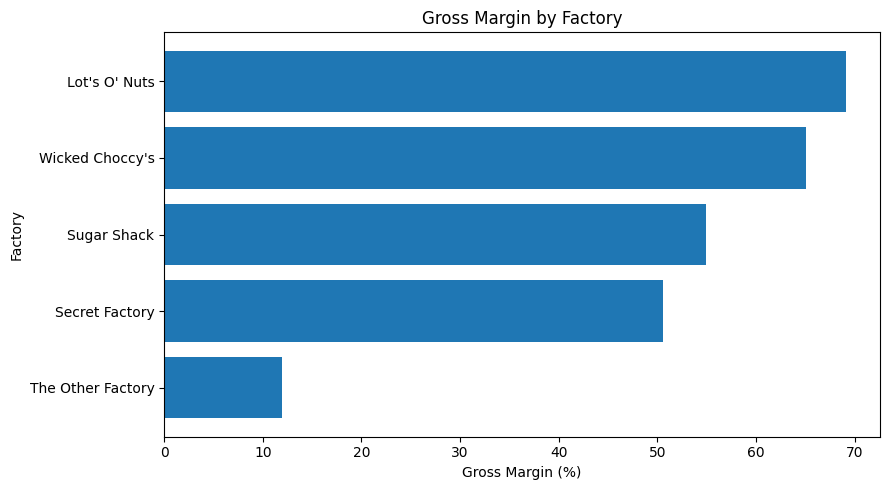

In [40]:
# Factory gross margin comparison

factory_margin = factory_analysis.sort_values(
    "Gross_Margin_%",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    factory_margin["Factory"],
    factory_margin["Gross_Margin_%"]
)

plt.xlabel("Gross Margin (%)")
plt.ylabel("Factory")
plt.title("Gross Margin by Factory")

plt.tight_layout()
plt.show()

### 9.4 Factory Locations

In [41]:
# Factory location data

factory_locations = pd.DataFrame({
    "Factory": [
        "Lot's O' Nuts",
        "Wicked Choccy's",
        "Sugar Shack",
        "Secret Factory",
        "The Other Factory"
    ],
    "Latitude": [
        32.881893,
        32.076176,
        48.119140,
        41.446333,
        35.117500
    ],
    "Longitude": [
        -111.768036,
        -81.088371,
        -96.181150,
        -90.565487,
        -89.971107
    ]
})

factory_analysis = factory_analysis.merge(
    factory_locations,
    on="Factory",
    how="left"
)

factory_analysis

,Factory,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units,Product_Count,Gross_Margin_%,Latitude,Longitude
0,Lot's O' Nuts,76340.15,23569.10,52771.05,21412,3,69.1,32.881893,-111.768036
1,Wicked Choccy's,55352.75,19299.18,36053.57,15863,2,65.1,32.076176,-81.088371
2,Secret Factory,8587.50,4242.80,4344.70,884,3,50.6,41.446333,-90.565487
3,The Other Factory,1282.25,1130.00,152.25,388,2,11.9,35.117500,-89.971107
4,Sugar Shack,220.98,99.75,121.23,107,5,54.9,48.119140,-96.181150


## 10. Key Findings Summary

1. **Profit is highly concentrated among a small number of products:**
   Just 5 products, representing approximately 33% of the product line, generate 95.1% of total gross profit. This indicates a high level of dependency on a limited group of products, particularly the Wonka Bar line.

2. **Chocolate is the strongest-performing division:**
   Chocolate contributes 92.9% of total revenue but generates 95.1% of total gross profit, with a gross margin of approximately 67.4%. This indicates that Chocolate converts its revenue into profit more efficiently than the other divisions.

3. **Product-level profitability is uneven:**
   The five Wonka Bar products maintain consistently strong gross margins in the 65–71% range. In contrast, Kazookles has a gross margin of only 7.7%, placing it significantly below the other products and making it the clearest candidate for pricing or cost intervention.

4. **Revenue and profit concentration are identical:**
   The same 5 of 15 products (all Wonka Bars) are needed to reach 80% of revenue and 80% of profit. The top 3 products alone generate 59.3% of gross profit and the top 5 generate 95.1% (HHI = 1,831), so dependency risk is rated HIGH. High-revenue products here are also the most profitable ones.

5. **Growth has been strong without a major deterioration in profitability:**
   From 2024 to 2025, total sales increased by approximately 44.6%, while gross profit increased by approximately 44.9%. The close alignment between sales and profit growth suggests that overall growth was achieved without a significant erosion in profitability.

6. **State and regional performance provides an additional profitability lens:**
   The state-level analysis evaluates sales, cost, gross profit, units, and gross margin to identify high-sales/low-margin locations. Regional analysis further compares revenue, cost, profit, and margin across the major regions, supporting the identification of geographic areas that may require pricing, cost, or commercial attention.

7. **Factory performance can be linked directly to product profitability:**
   Product-to-factory mapping enables sales, cost, gross profit, product count, and gross margin to be compared across the five factories. This provides an operational perspective on where profitable and low-margin product lines are being produced.

8. **Cost structure requires targeted attention for low-margin products:**
   Kazookles is positioned close to the break-even line in the cost-versus-sales analysis. A pricing review, supplier/cost renegotiation, or product-level strategic review should therefore be considered before continuing to scale the product.

9. **Data-quality limitation:**
   The Ship Date field was found to be unreliable because its values occur several years after the corresponding Order Date. Consequently, Order Date and Order Year are used for time-based analysis, while Ship Date is excluded from growth and temporal analysis.


## 11. Dashboard Visuals

The following visuals summarize the key business performance findings from the analysis. They are designed to provide dashboard-ready views of revenue, profitability, product performance, division performance, geographic performance, and operational performance.

### 11.1 Year-wise Sales & Gross Profit

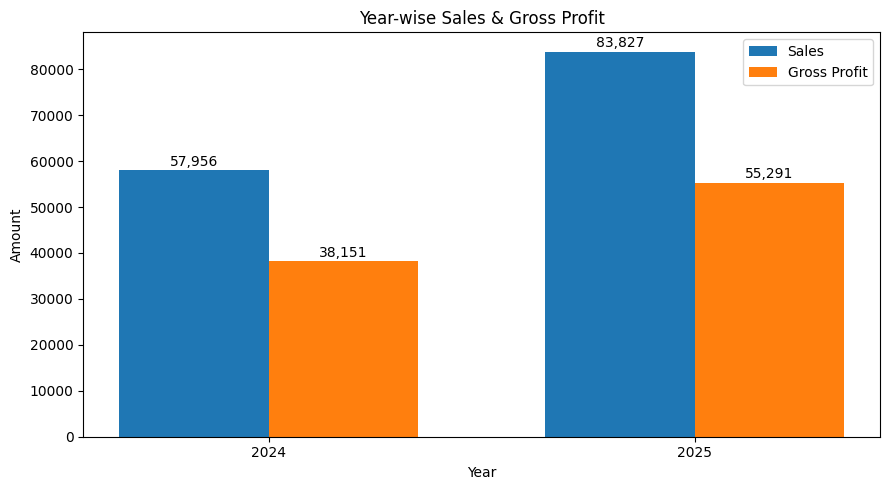

In [42]:
fig, ax = plt.subplots(figsize=(9, 5))

x = range(len(yearly_sales))
width = 0.35

bars1 = ax.bar(
    [i - width/2 for i in x],
    yearly_sales["Total_Sales"],
    width=width,
    label="Sales"
)

bars2 = ax.bar(
    [i + width/2 for i in x],
    yearly_sales["Total_Gross_Profit"],
    width=width,
    label="Gross Profit"
)

ax.set_xticks(list(x))
ax.set_xticklabels(yearly_sales["Year"])
ax.set_xlabel("Year")
ax.set_ylabel("Amount")
ax.set_title("Year-wise Sales & Gross Profit")
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1000,
            f"{bar.get_height():,.0f}",
            ha="center"
        )

plt.tight_layout()
plt.show()

### 11.2 Sales by Region

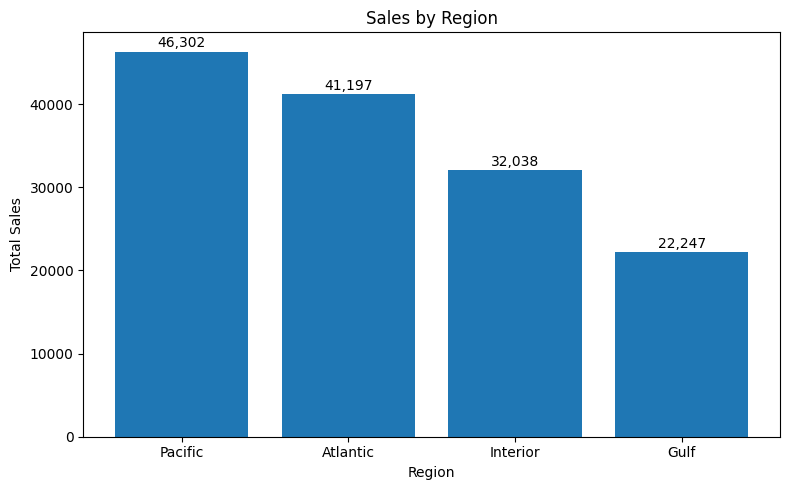

In [43]:
region_analysis = df.groupby("Region").agg(
    Total_Sales=("Sales", "sum"),
    Total_Cost=("Cost", "sum"),
    Total_Gross_Profit=("Gross Profit", "sum"),
    Total_Units=("Units", "sum")
).reset_index()

region_analysis["Profit_Margin_%"] = (
    region_analysis["Total_Gross_Profit"] /
    region_analysis["Total_Sales"] * 100
)

region_analysis = region_analysis.sort_values(
    "Total_Sales",
    ascending=False
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    region_analysis["Region"],
    region_analysis["Total_Sales"]
)

ax.set_xlabel("Region")
ax.set_ylabel("Total Sales")
ax.set_title("Sales by Region")

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 500,
        f"{bar.get_height():,.0f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

### 11.3 Sales by Product

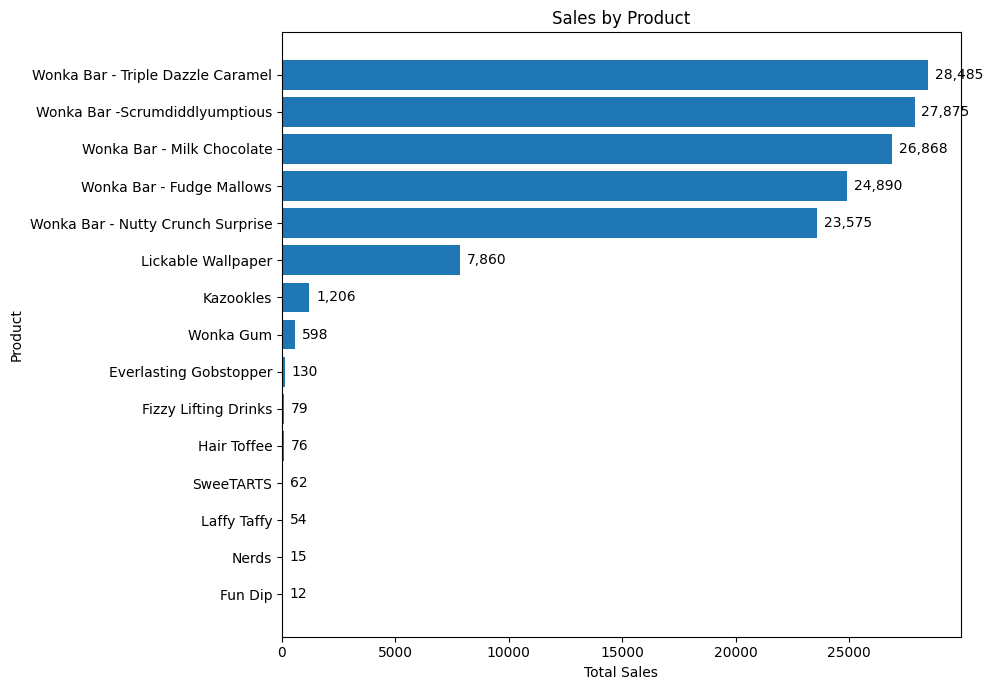

In [44]:
product_sales = product.sort_values(
    "Total_Sales",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    product_sales["Product Name"],
    product_sales["Total_Sales"]
)

ax.set_xlabel("Total Sales")
ax.set_ylabel("Product")
ax.set_title("Sales by Product")

for bar in bars:
    ax.text(
        bar.get_width() + 300,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

### 11.4 Sales by Division

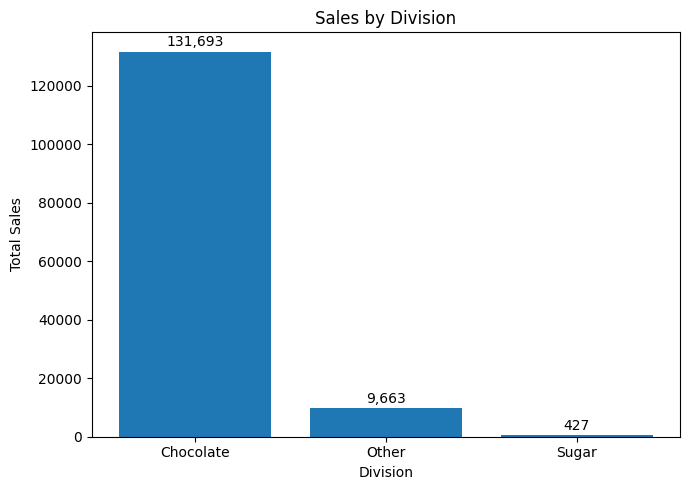

In [45]:
division_sales = division.sort_values(
    "Total_Sales",
    ascending=False
)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    division_sales["Division"],
    division_sales["Total_Sales"]
)

ax.set_xlabel("Division")
ax.set_ylabel("Total Sales")
ax.set_title("Sales by Division")

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2000,
        f"{bar.get_height():,.0f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

### 11.5 Sales by Ship Mode

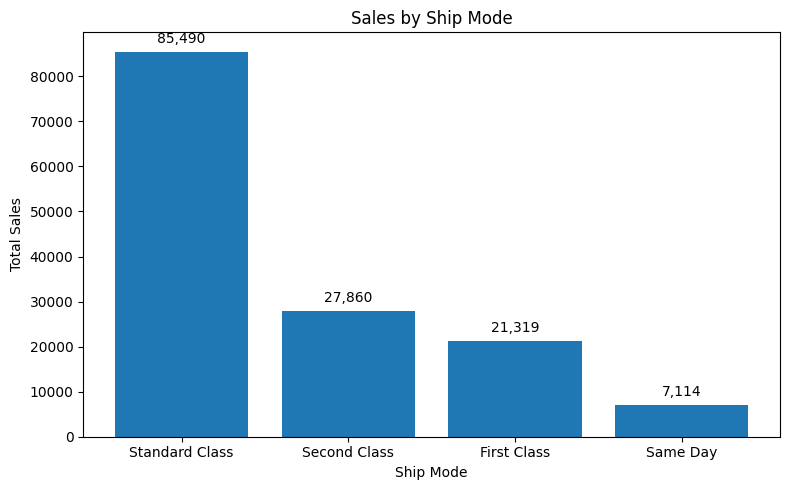

In [46]:
ship_analysis = df.groupby("Ship Mode").agg(
    Total_Sales=("Sales", "sum"),
    Total_Cost=("Cost", "sum"),
    Total_Gross_Profit=("Gross Profit", "sum"),
    Total_Units=("Units", "sum")
).reset_index()

ship_analysis["Profit_Margin_%"] = (
    ship_analysis["Total_Gross_Profit"] /
    ship_analysis["Total_Sales"] * 100
)

ship_analysis = ship_analysis.sort_values(
    "Total_Sales",
    ascending=False
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    ship_analysis["Ship Mode"],
    ship_analysis["Total_Sales"]
)

ax.set_xlabel("Ship Mode")
ax.set_ylabel("Total Sales")
ax.set_title("Sales by Ship Mode")

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2000,
        f"{bar.get_height():,.0f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

### 11.6 Revenue Pareto Analysis

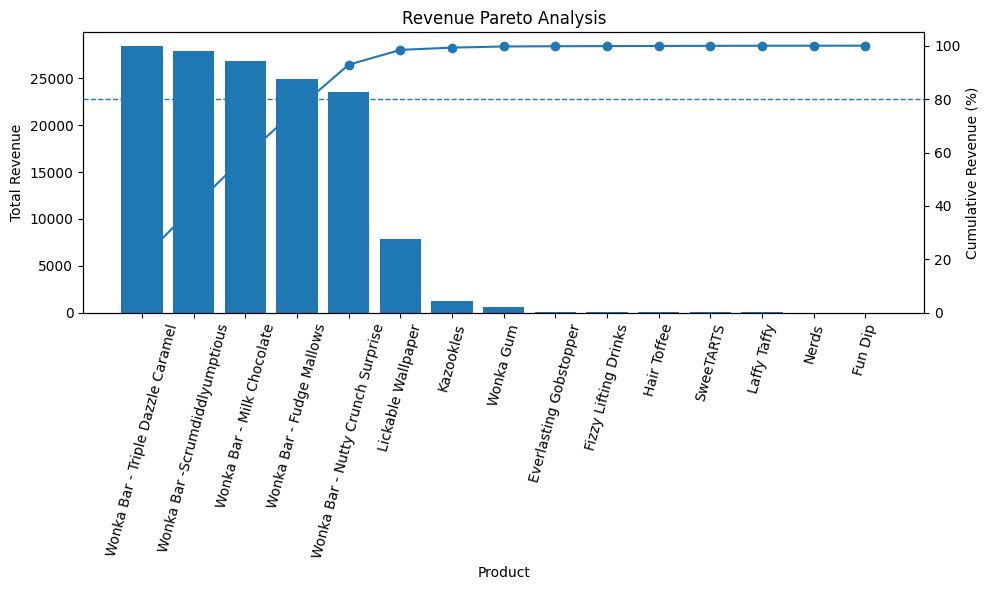

In [47]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(
    revenue_pareto["Product Name"],
    revenue_pareto["Total_Sales"]
)

ax1.set_xlabel("Product")
ax1.set_ylabel("Total Revenue")
ax1.tick_params(axis="x", rotation=75)

ax2 = ax1.twinx()

ax2.plot(
    revenue_pareto["Product Name"],
    revenue_pareto["Cumulative_Revenue_%"],
    marker="o"
)

ax2.axhline(
    80,
    linestyle="--",
    linewidth=1
)

ax2.set_ylabel("Cumulative Revenue (%)")
ax2.set_ylim(0, 105)

plt.title("Revenue Pareto Analysis")
plt.tight_layout()
plt.show()

### 11.7 Profit Pareto Analysis

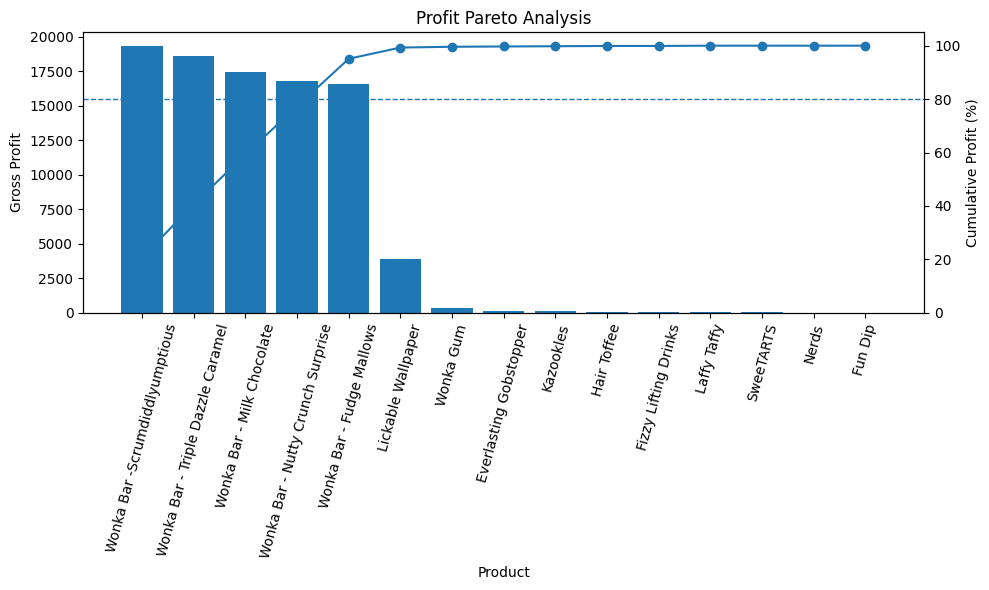

In [48]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(
    pareto["Product Name"],
    pareto["Total_Gross_Profit"]
)

ax1.set_xlabel("Product")
ax1.set_ylabel("Gross Profit")
ax1.tick_params(axis="x", rotation=75)

ax2 = ax1.twinx()

ax2.plot(
    pareto["Product Name"],
    pareto["Cumulative_Profit_%"],
    marker="o"
)

ax2.axhline(
    80,
    linestyle="--",
    linewidth=1
)

ax2.set_ylabel("Cumulative Profit (%)")
ax2.set_ylim(0, 105)

plt.title("Profit Pareto Analysis")
plt.tight_layout()
plt.show()

### 11.8 Factory Gross Margin

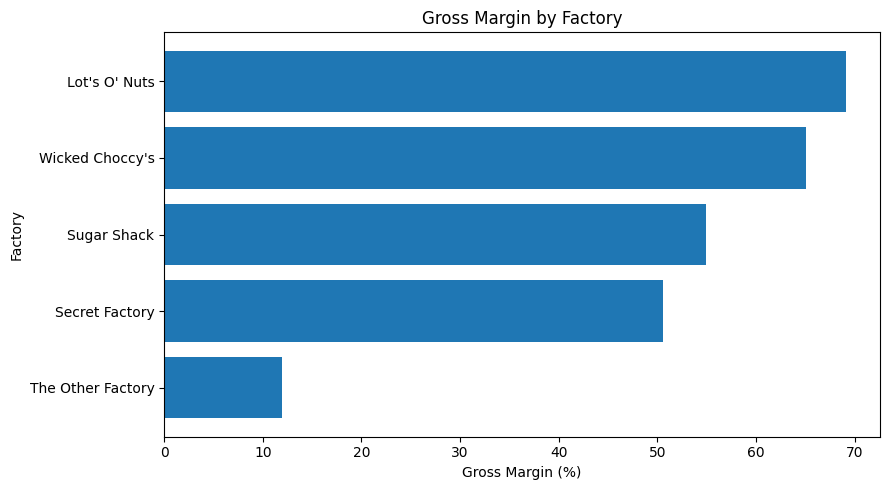

In [49]:
factory_margin = factory_analysis.sort_values(
    "Gross_Margin_%",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    factory_margin["Factory"],
    factory_margin["Gross_Margin_%"]
)

plt.xlabel("Gross Margin (%)")
plt.ylabel("Factory")
plt.title("Gross Margin by Factory")

plt.tight_layout()
plt.show()

### 11.9 State-Level Profitability

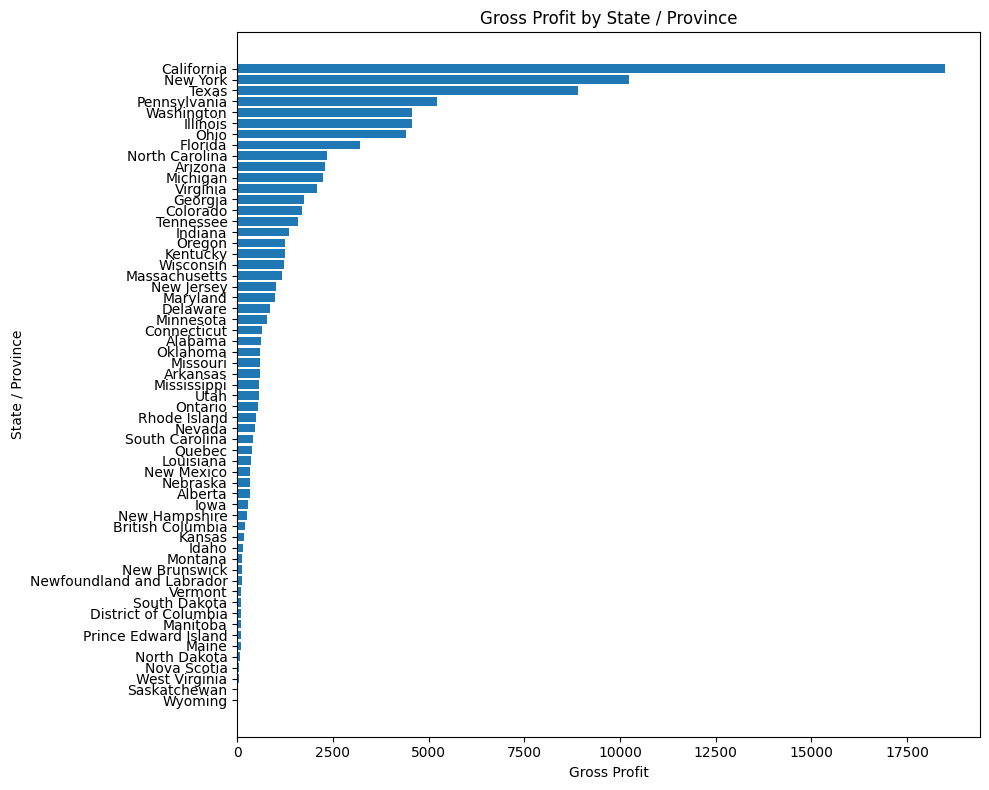

In [50]:
state_plot = state_analysis.sort_values(
    "Total_Gross_Profit",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    state_plot["State/Province"],
    state_plot["Total_Gross_Profit"]
)

ax.set_xlabel("Gross Profit")
ax.set_ylabel("State / Province")
ax.set_title("Gross Profit by State / Province")

plt.tight_layout()
plt.show()

In [51]:
### 11.10 Product Profitability Matrix

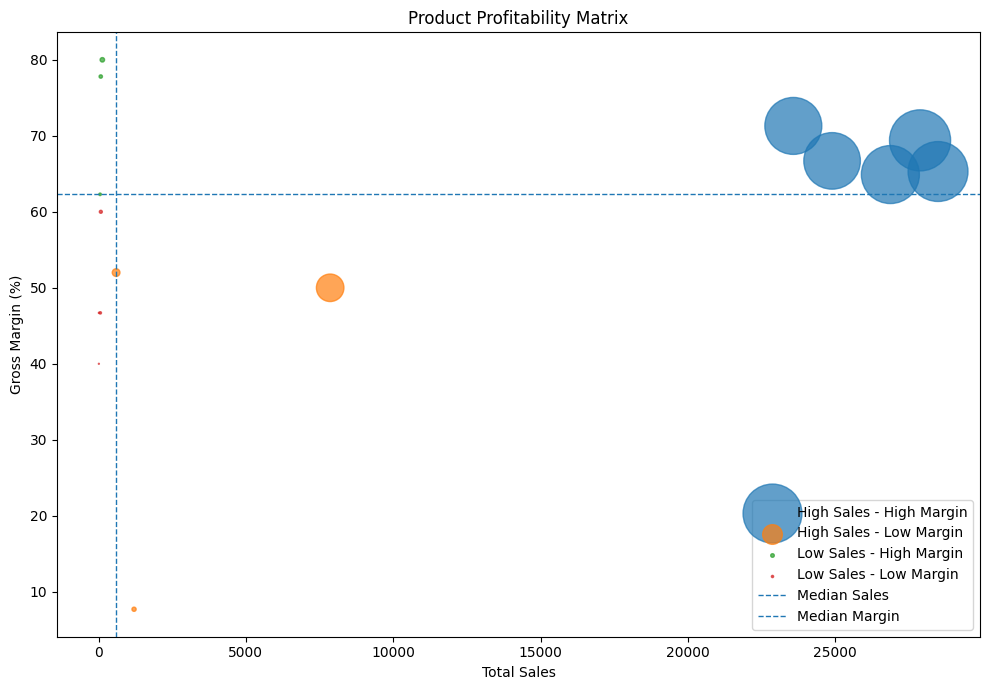

In [52]:
plt.figure(figsize=(10, 7))

for category in product["Profitability_Class"].unique():

    subset = product[
        product["Profitability_Class"] == category
    ]

    plt.scatter(
        subset["Total_Sales"],
        subset["Gross_Margin_%"],
        s=subset["Total_Gross_Profit"] / 10,
        alpha=0.7,
        label=category
    )

plt.axvline(
    sales_median,
    linestyle="--",
    linewidth=1,
    label="Median Sales"
)

plt.axhline(
    margin_median,
    linestyle="--",
    linewidth=1,
    label="Median Margin"
)

plt.xlabel("Total Sales")
plt.ylabel("Gross Margin (%)")
plt.title("Product Profitability Matrix")
plt.legend()

plt.tight_layout()
plt.show()

### 11.11 Dashboard Findings & Insights

The dashboard visualizations provide a consolidated view of product, division, geographic, factory, revenue, and profit performance. The key insights observed from the visual analysis are summarized below.

1. **Sales and profit growth remained closely aligned:**
   Year-wise analysis shows that sales increased by approximately 44.6% from 2024 to 2025, while gross profit increased by approximately 44.9%. This indicates that the increase in sales was accompanied by a broadly similar increase in profitability.

2. **Chocolate dominates overall business performance:**
   The division-level visualization shows that Chocolate accounts for the majority of total sales and gross profit. It contributes approximately 92.9% of revenue and 95.1% of gross profit, with a gross margin of approximately 67.4%.

3. **Profitability is concentrated in a small number of products:**
   The profit Pareto analysis shows that only 5 products, representing approximately 33% of the product portfolio, generate around 95.1% of total gross profit. This indicates a high dependency on a small group of profitable products.

4. **Revenue concentration and profit concentration are not identical:**
   The Revenue Pareto analysis identifies the products responsible for reaching 80% of total revenue, while the Profit Pareto analysis highlights the products responsible for generating the majority of gross profit. Comparing the two helps distinguish high-selling products from products that actually create the greatest financial value.

5. **Wonka Bar products are consistently strong performers:**
   The product-level visualizations and profitability matrix show that the Wonka Bar products occupy the stronger profitability categories, with gross margins generally in the 65–71% range. Their contribution is therefore important to the overall profitability of the business.

6. **Kazookles is a clear profitability concern:**
   Kazookles has a gross margin of approximately 7.7%, substantially below the other products. The cost-versus-margin analysis places it close to the break-even area, suggesting that pricing, production cost, or product strategy should be reviewed.

7. **Geographic performance varies across states and regions:**
   The state-level visualization highlights differences in sales and gross profit across locations. Comparing sales with gross margin helps identify areas where strong revenue does not necessarily translate into equally strong profitability.

8. **Factory performance provides an operational profitability perspective:**
   The factory analysis shows differences in sales, gross profit, and gross margin across production facilities. Linking products to their respective factories helps identify whether profitability patterns are concentrated within particular production locations.

9. **The Product Profitability Matrix separates sales strength from margin strength:**
   The matrix categorizes products using sales and gross-margin performance. This makes it easier to identify products that are high-sales/high-margin, high-sales/low-margin, low-sales/high-margin, and low-sales/low-margin, supporting targeted managerial decisions.

10. **Overall management implication:**
    The dashboard indicates that Nassau Candy Distributor has strong overall growth and a highly profitable core product portfolio, but profitability is heavily concentrated. Management should protect the performance of high-margin products while reviewing low-margin products such as Kazookles and monitoring geographic, factory, and revenue concentration risks.
